<a href="https://colab.research.google.com/github/fbou-mtl/teluq-sci1402/blob/main/TN3_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

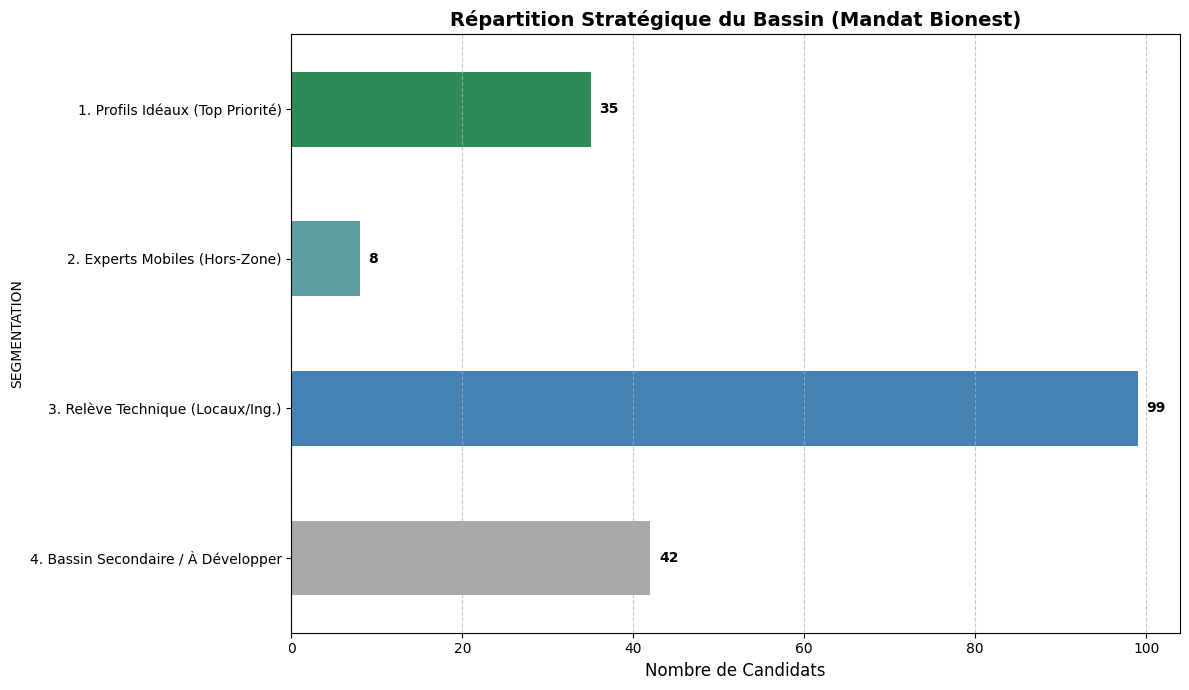


--- RÉSUMÉ DES SEGMENTS ---
SEGMENTATION
1. Profils Idéaux (Top Priorité)       35
2. Experts Mobiles (Hors-Zone)          8
3. Relève Technique (Locaux/Ing.)      99
4. Bassin Secondaire / À Développer    42
Name: count, dtype: int64


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement (Assure-toi que le fichier est bien présent à gauche)
df = pd.read_csv('SCI1402-BDD.csv')

# --- LOGIQUE DE SCORING ---
def calculer_score(row):
    score = 0
    if row['MEMBRE OIQ?'] == 'OUI': score += 40
    if row["GESTION D'ÉQUIPE?"] == 'OUI': score += 30
    if row['LOCALISATION RECHERCHÉE?'] == 'OUI': score += 30
    return score

df['SCORE_FINAL'] = df.apply(calculer_score, axis=1)

# --- SEGMENTATION AVEC LIBELLÉS CLAIRS ---
def segmenter_profil(row):
    if row['SCORE_FINAL'] == 100:
        return "1. Profils Idéaux (Top Priorité)"
    elif row['MEMBRE OIQ?'] == 'OUI' and row["GESTION D'ÉQUIPE?"] == 'OUI':
        return "2. Experts Mobiles (Hors-Zone)"
    elif row['MEMBRE OIQ?'] == 'OUI' and row['LOCALISATION RECHERCHÉE?'] == 'OUI':
        return "3. Relève Technique (Locaux/Ing.)"
    else:
        return "4. Bassin Secondaire / À Développer"

df['SEGMENTATION'] = df.apply(segmenter_profil, axis=1)

# --- VISUALISATION EN ORDRE 1-2-3-4 ---
plt.figure(figsize=(12, 7))

# On trie par index pour forcer l'ordre 1, 2, 3, 4
stats_segments = df['SEGMENTATION'].value_counts().sort_index(ascending=False)

stats_segments.plot(kind='barh', color=['#A9A9A9', '#4682B4', '#5F9EA0', '#2E8B57'])

plt.title("Répartition Stratégique du Bassin (Mandat Bionest)", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de Candidats", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajout des chiffres au bout des barres pour plus de clarté
for i, v in enumerate(stats_segments):
    plt.text(v + 1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Affichage du résumé textuel
print("\n--- RÉSUMÉ DES SEGMENTS ---")
print(df['SEGMENTATION'].value_counts().sort_index())